# 03 — Shot Charts

This notebook builds two types of shot charts on top of a regulation NBA half-court:

1. **Make/miss scatter chart** — every shot plotted as a dot, colored by outcome
2. **Hex-bin efficiency chart** — hexagons sized by volume, colored by eFG% vs. league average

Both chart types use a shared `draw_court()` function stored in `src/court.py`. Saving it there means every future notebook can import and reuse it without copy-pasting.

**Section 1** covers building and verifying that court function before any shot data is added.

## 1.1 — Imports and Path Setup

This notebook is in `notebooks/` but needs to import from `src/`. We add the project root to Python's module search path so `from src.court import draw_court` works cleanly from any notebook in this project.

We also create the output directory for saved charts here, so later cells can write PNGs without checking.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
from matplotlib.cm import ScalarMappable
from pathlib import Path

# ── Project paths ─────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Add project root to sys.path so `from src.X import Y` works
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.court import draw_court
from src.metrics import assign_zone

PROCESSED_FILE = PROJECT_ROOT / "data" / "processed" / "shots_cleaned.csv"
CHARTS_DIR     = PROJECT_ROOT / "outputs" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Data   : {PROCESSED_FILE}")
print(f"Charts : {CHARTS_DIR}")

Setup complete.
Data   : /Users/narayanlekhi/Documents/GitHub/nba-shot-analytics/data/processed/shots_cleaned.csv
Charts : /Users/narayanlekhi/Documents/GitHub/nba-shot-analytics/outputs/charts


## 1.2 — Render a Blank Court (Light Background)

We call `draw_court()` with no arguments to render a blank court and visually confirm every element is drawn correctly before adding shot data.

**What the court should show, from bottom to top:**
- The **baseline** as a horizontal line at the very bottom
- The **basket** (small circle) and **backboard** (short thick horizontal line) just above the baseline
- The **restricted area arc** (4-ft radius semicircle) wrapping around the basket
- The **paint rectangle** (16 ft wide, 19 ft tall)
- The **free throw circle**: solid arc above the free throw line, dashed arc below it (inside the paint)
- The **corner 3-point lines**: vertical straight lines at ±22 ft, connecting the baseline to the arc break
- The **above-break 3-point arc**: the curved portion connecting both corner lines over the top of the key
- The **sidelines**, **half-court line**, and **center circle arc** at the very top

If the corner straight lines don't visually connect flush to the arc, the geometry is off — but they should, because both use `_CORNER_3_BREAK_Y` computed from the same formula.

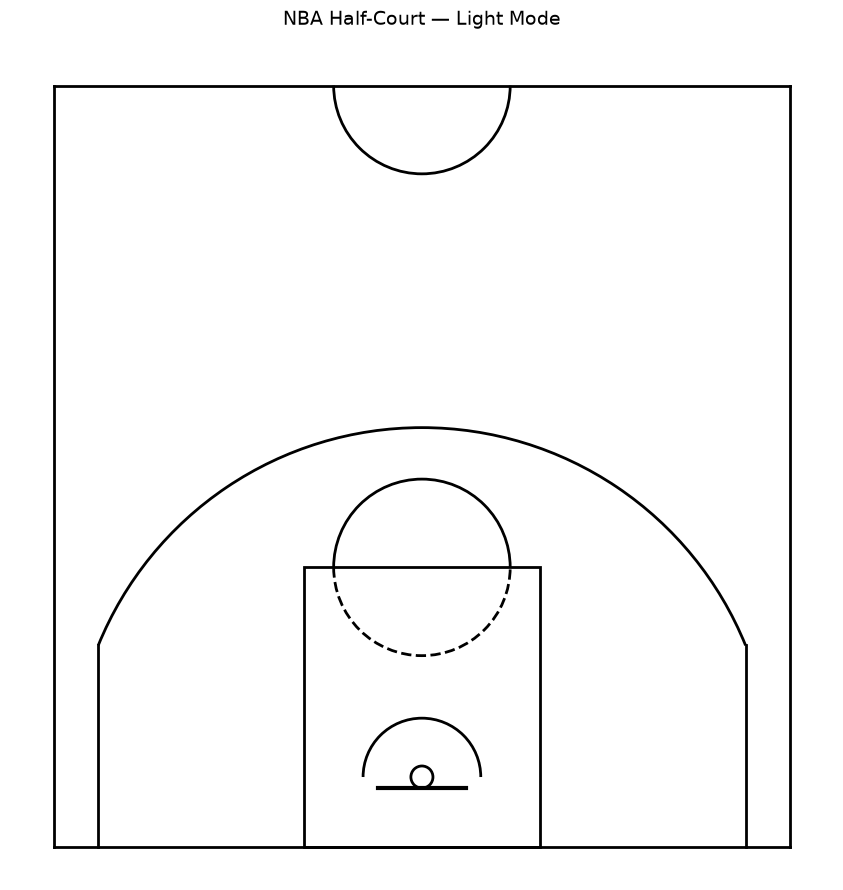

In [2]:
fig, ax = plt.subplots(figsize=(10, 9))
draw_court(ax=ax)
ax.set_title("NBA Half-Court — Light Mode", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## 1.3 — Render a Blank Court (Dark Background)

The dark background mode is useful for hex-bin charts in Section 3, where the red-white-green colormap reads more clearly against dark navy than against white. We verify it now so we know the `dark_bg=True` parameter works as expected.

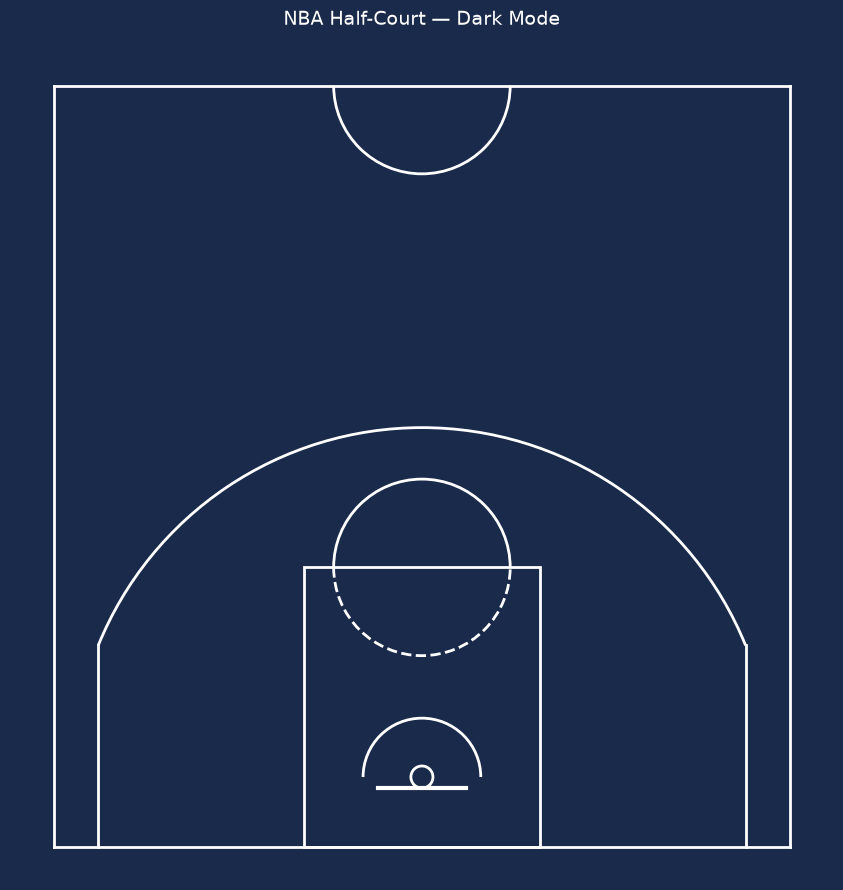

In [3]:
fig, ax = plt.subplots(figsize=(10, 9))
fig.set_facecolor("#1a2a4a")   # match the dark court background to the figure background
draw_court(ax=ax, dark_bg=True)
ax.set_title("NBA Half-Court — Dark Mode", fontsize=14, pad=12, color="white")
plt.tight_layout()
plt.show()

## Section 2 — Make/Miss Scatter Chart (Stephen Curry)

A make/miss chart plots every shot attempt as an individual dot on the court — green for makes, red for misses. It's the most direct way to see where a player shoots from and how those attempts are distributed across the court.

We use `draw_court()` from Section 1 as the base layer and overlay the shot dots on top. Marker transparency (alpha) is essential here: Curry takes a high volume of 3-point attempts, so without alpha the above-break zones would be a solid wall of overlapping dots.

### 2.1 — Load Cleaned Data and Filter to Stephen Curry

We load `data/processed/shots_cleaned.csv` — the output of notebook 02 — and filter to Curry's rows only. We print a quick check to confirm the filter found him and that the shot counts look reasonable before building the chart.

All coordinate columns (`LOC_X_FT`, `LOC_Y_FT`) are already in feet with the basket at (0, 0), matching the court drawing's coordinate system exactly. No transformation is needed — positive Y runs toward half court, positive X is court-right, which aligns with matplotlib's default axes orientation.

In [4]:
# Re-derive paths in case the kernel was restarted between sections
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PROCESSED_FILE = PROJECT_ROOT / "data" / "processed" / "shots_cleaned.csv"

all_shots = pd.read_csv(PROCESSED_FILE)

# Filter to Curry — NAME was set from DISPLAY_FIRST_LAST in notebook 01
curry = all_shots[all_shots["NAME"] == "Stephen Curry"].copy()

print(f"Total rows loaded       : {len(all_shots):,}")
print(f"Curry rows              : {len(curry):,}")
print(f"Curry makes             : {curry['SHOT_MADE_FLAG'].sum():,}")
print(f"Curry misses            : {(curry['SHOT_MADE_FLAG'] == 0).sum():,}")
print(f"Curry FG%               : {curry['SHOT_MADE_FLAG'].mean():.1%}")
print(f"\nCoordinate sanity check:")
print(f"  LOC_X_FT range: {curry['LOC_X_FT'].min():.1f} → {curry['LOC_X_FT'].max():.1f} ft")
print(f"  LOC_Y_FT range: {curry['LOC_Y_FT'].min():.1f} → {curry['LOC_Y_FT'].max():.1f} ft")
print(f"\nZone breakdown:")
print(curry["ZONE"].value_counts().to_string())

Total rows loaded       : 219,160
Curry rows              : 799
Curry makes             : 374
Curry misses            : 425
Curry FG%               : 46.8%

Coordinate sanity check:
  LOC_X_FT range: -24.0 → 23.7 ft
  LOC_Y_FT range: -3.4 → 39.4 ft

Zone breakdown:
ZONE
Above Break 3 Right     178
Above Break 3 Left      152
Restricted Area         122
Above Break 3 Center    121
Paint (Non-RA)          101
Mid-Range Left           41
Mid-Range Right          36
Left Corner 3            20
Mid-Range Center         15
Right Corner 3           13


### 2.2 — Build the Chart

We draw the court first, then layer the shot scatter on top. A few choices made here:

- **Misses plotted before makes** so that in areas where they overlap, green makes appear on top — this keeps the chart readable in the high-density 3-point zones
- **X markers for misses, circles for makes** — the X shape is visually distinct from the circle and reads as a "miss" intuitively even without the legend
- **alpha=0.5** — at this transparency level, a single shot is still clearly visible, but a cluster of 10+ overlapping shots in the restricted area doesn't become an opaque blob
- **zorder** — explicit draw order ensures makes always sit above misses even in dense zones

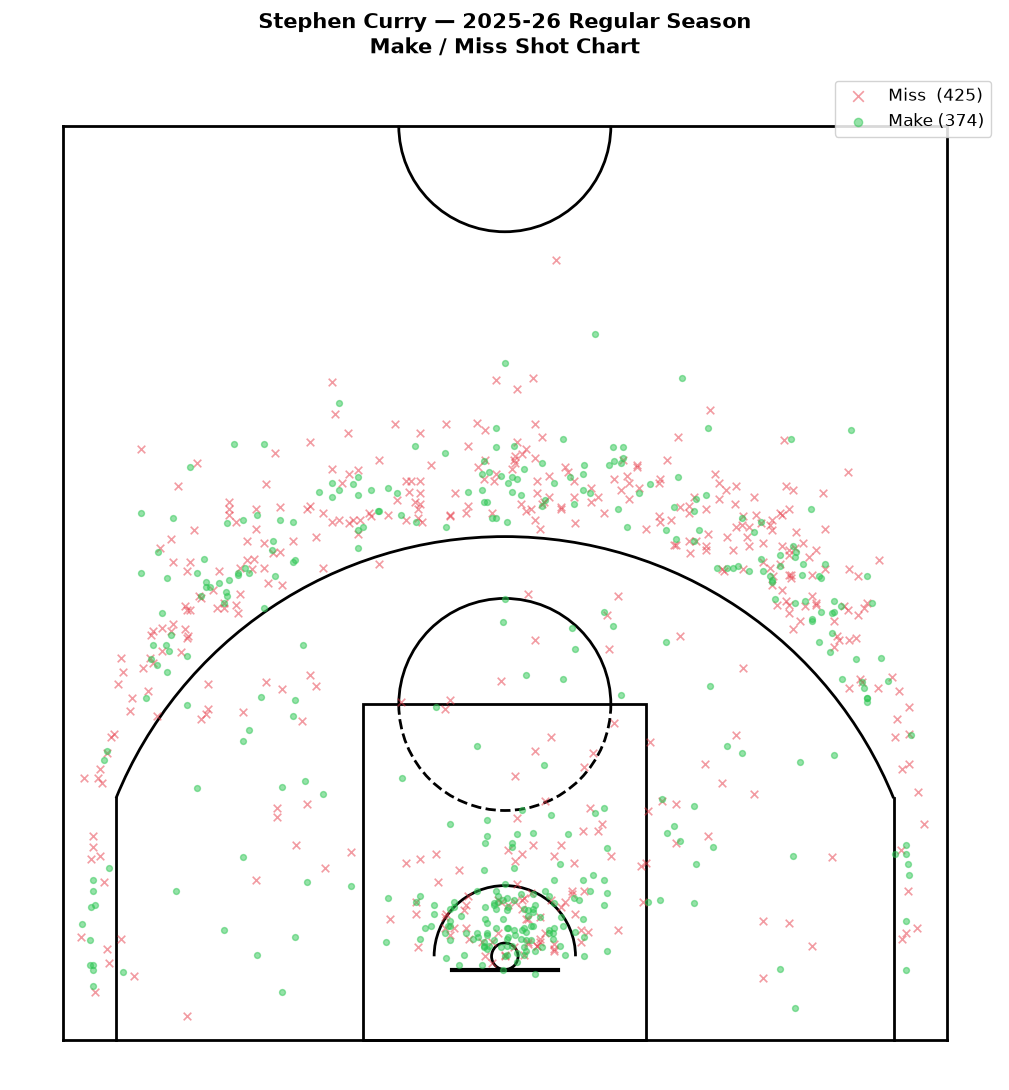

In [5]:
CHARTS_DIR = PROJECT_ROOT / "outputs" / "charts"

makes  = curry[curry["SHOT_MADE_FLAG"] == 1]
misses = curry[curry["SHOT_MADE_FLAG"] == 0]

fig, ax = plt.subplots(figsize=(12, 11))

# Court as base layer
draw_court(ax=ax, lw=2)

# Misses — plotted first so makes appear on top in overlap zones
ax.scatter(
    misses["LOC_X_FT"], misses["LOC_Y_FT"],
    marker="x", c="#e63946",
    s=30, linewidths=1.2,
    alpha=0.5, zorder=2,
    label=f"Miss  ({len(misses):,})",
)

# Makes — plotted second so they sit above misses
ax.scatter(
    makes["LOC_X_FT"], makes["LOC_Y_FT"],
    marker="o", c="#2dc653",
    s=18,
    alpha=0.5, zorder=3,
    label=f"Make ({len(makes):,})",
)

ax.set_title(
    "Stephen Curry — 2025-26 Regular Season\nMake / Miss Shot Chart",
    fontsize=15, fontweight="bold", pad=14,
)

ax.legend(
    loc="upper right",
    fontsize=12,
    framealpha=0.85,
    markerscale=1.4,
)

plt.tight_layout()
plt.show()

### 2.3 — Save and Verify

We save the figure at 150 DPI then print the makes, misses, and total so you can cross-reference against the raw counts from Cell 10. These numbers must match exactly — any discrepancy means a filtering step dropped or duplicated rows between the data load and the scatter plot.

In [6]:
output_path = CHARTS_DIR / "curry_make_miss_2025_26.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

print(f"Saved  : {output_path}")
print(f"Size   : {output_path.stat().st_size / 1024:.0f} KB")

print(f"\nShot totals on chart:")
print(f"  Makes  : {len(makes):,}")
print(f"  Misses : {len(misses):,}")
print(f"  Total  : {len(makes) + len(misses):,}")

# Confirm this matches the filtered DataFrame exactly
assert len(makes) + len(misses) == len(curry), \
    "Mismatch — chart total does not equal filtered DataFrame row count"
print(f"\nVerification passed — all {len(curry):,} Curry shots are accounted for.")

Saved  : /Users/narayanlekhi/Documents/GitHub/nba-shot-analytics/outputs/charts/curry_make_miss_2025_26.png
Size   : 188 KB

Shot totals on chart:
  Makes  : 374
  Misses : 425
  Total  : 799

Verification passed — all 799 Curry shots are accounted for.


## Section 3 — Hex-Bin Efficiency Chart (Stephen Curry)

A hex-bin chart divides the court into a grid of hexagonal bins. Each hexagon encodes two variables simultaneously:

- **Size** → shot volume. Larger hexagons mean more attempts from that court area.
- **Color** → eFG% relative to league average for the same NBA zone. Green means Curry is more efficient than the league at that spot; red means he's less efficient; white means he matches league average.

Hexagons with fewer than 20 attempts are shown as small neutral-gray markers and excluded from the color scale — their eFG% estimate isn't reliable enough to color meaningfully.

The league averages come from **all players** in `shots_cleaned.csv`, so the meaningfully.

The league averages come from **all players** in `shots_cleaned.csv`, so the comparison baseline reflects the whole 2025-26 season, not just Curry's peers at each location.

### 3.1 — Compute League Average eFG% Per Zone

We group the full dataset by NBA zone and compute eFG% across all players. This becomes the baseline for the diverging colormap: a hex bin colored based on how far Curry's local eFG% deviates from this number.

We use the `assign_zone()` function from `src/metrics.py` to map each hex bin center to one of the 11 NBA zones — the same function used in notebook 02, so the zone boundaries are guaranteed to be identical.

In [7]:
CHARTS_DIR = PROJECT_ROOT / "outputs" / "charts"

# ── League average eFG% per zone (all players, all teams) ──────────────────
def zone_efg(df: pd.DataFrame) -> pd.Series:
    """Return eFG% per zone for a given DataFrame."""
    g = df.groupby("ZONE")
    fga  = g["SHOT_MADE_FLAG"].count()
    fgm  = g["SHOT_MADE_FLAG"].sum()
    fg3m = (df["SHOT_MADE_FLAG"] * df["IS_3PT"]).groupby(df["ZONE"]).sum()
    return ((fgm + 0.5 * fg3m) / fga).rename("EFG_PCT")

league_efg = zone_efg(all_shots)  # all_shots loaded in Section 2

print("League average eFG% per zone (2025-26):\n")
print(league_efg.sort_values(ascending=False).round(3).to_string())

League average eFG% per zone (2025-26):

ZONE
Backcourt               1.000
Restricted Area         0.671
Left Corner 3           0.580
Right Corner 3          0.579
Above Break 3 Center    0.529
Above Break 3 Left      0.528
Above Break 3 Right     0.520
Paint (Non-RA)          0.445
Mid-Range Center        0.427
Mid-Range Right         0.421
Mid-Range Left          0.405


### 3.2 — Build the Hex-Bin Chart

The chart is built in five layers, in this order:

1. **Draw the court** as the base layer (same as Section 2)
2. **Run hexbin twice** on Curry's shots — once to get counts per bin, once to get eFG% numerator sums per bin — then remove both hexbin outputs and replace them with our own custom patches
3. **Assign each bin center to an NBA zone** using `assign_zone()`, then look up the league average for that zone to compute the delta
4. **Draw gray patches** for low-sample bins (< 20 attempts), sized at 15% of natural hex size
5. **Draw colored patches** for the remaining bins, sized by shot volume (using square-root scaling so patch *area* is proportional to count) and colored by eFG% delta using a red-white-green diverging colormap

The two-pass hexbin approach guarantees that both metrics (count and eFG%) are binned on exactly the same spatial grid — no approximation from nearest-center assignment.

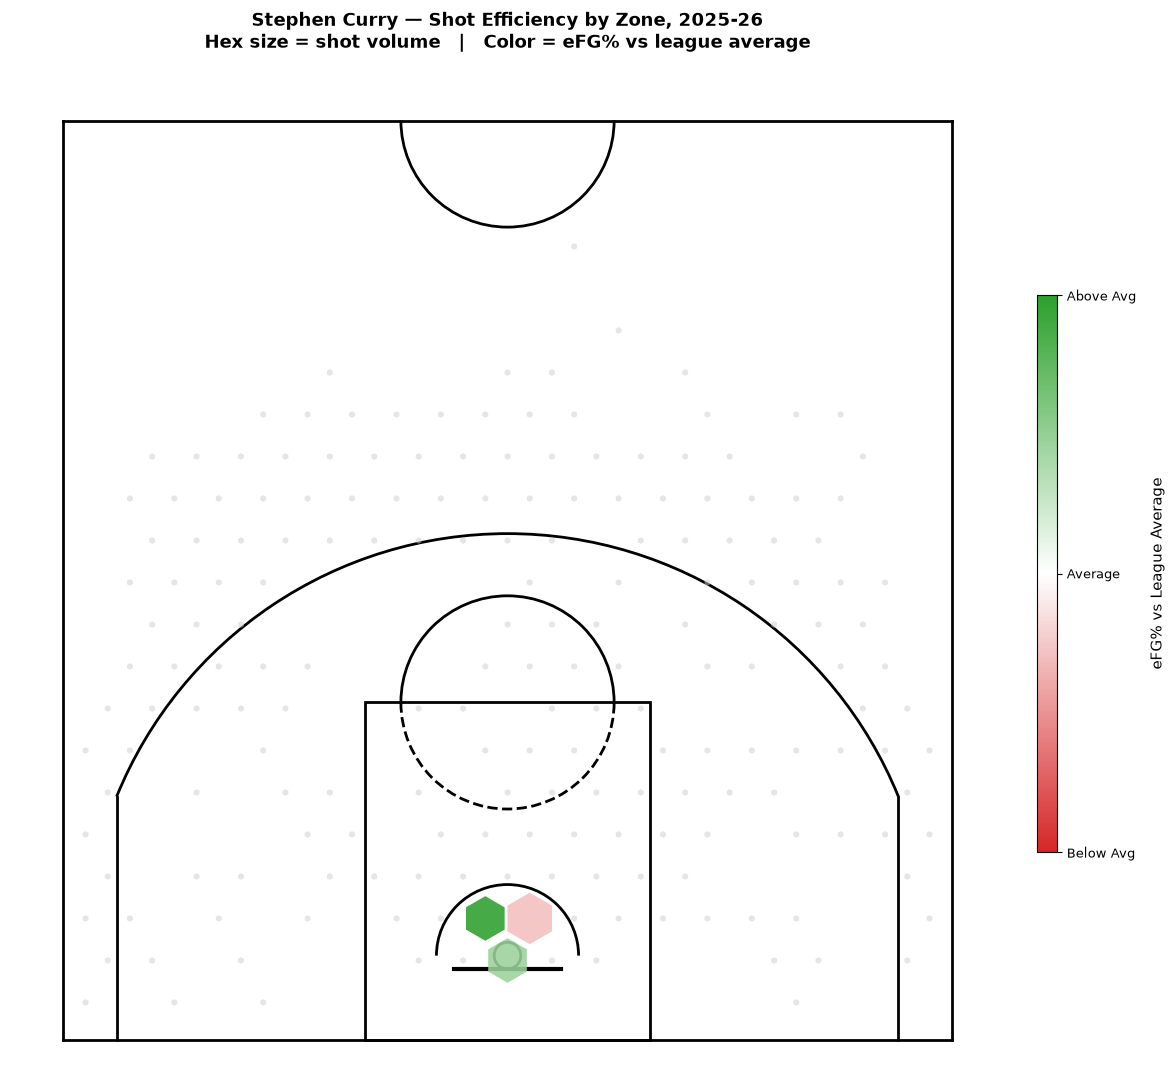

In [8]:
GRIDSIZE   = 20          # hexagons across the x-direction (court width)
EXTENT     = (-25, 25, -5, 47)   # xmin, xmax, ymin, ymax in feet
MIN_COUNT  = 20          # bins below this threshold → gray (low sample)

# ── Red-white-green diverging colormap ────────────────────────────────────
rg_cmap = mcolors.LinearSegmentedColormap.from_list(
    "efg_div", ["#d62728", "white", "#2ca02c"]
)

# ── Build figure ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 11))
draw_court(ax=ax, lw=2)

# ── Pass 1: counts per hex bin ────────────────────────────────────────────
hb_cnt = ax.hexbin(
    curry["LOC_X_FT"], curry["LOC_Y_FT"],
    gridsize=GRIDSIZE, extent=EXTENT, mincnt=1,
)
centers   = np.array(hb_cnt.get_offsets())   # (N_bins, 2) in data coords (feet)
counts    = np.array(hb_cnt.get_array())      # (N_bins,)
# Extract the template hexagon — vertices relative to (0,0) in data coords
hex_verts = hb_cnt.get_paths()[0].vertices.copy()   # (7, 2); last row closes the path
natural_radius = np.max(np.linalg.norm(hex_verts, axis=1))
hb_cnt.remove()

# ── Pass 2: eFG% numerator sum per bin ───────────────────────────────────
# eFG% = (FGM + 0.5×3PM)/FGA = sum(made × (1 + 0.5×is3pt)) / count
efg_num = curry["SHOT_MADE_FLAG"] * (1 + 0.5 * curry["IS_3PT"])

hb_efg = ax.hexbin(
    curry["LOC_X_FT"], curry["LOC_Y_FT"],
    C=efg_num.values,
    gridsize=GRIDSIZE, extent=EXTENT,
    reduce_C_function=np.sum, mincnt=1,
)
efg_sums = np.array(hb_efg.get_array())
hb_efg.remove()

bin_efg_pct = efg_sums / counts

# ── Map each bin center to an NBA zone → league average for that zone ─────
bin_zones   = [assign_zone(cx, cy) for cx, cy in centers]
league_avg  = np.array([league_efg.get(z, np.nan) for z in bin_zones])
delta       = bin_efg_pct - league_avg   # positive = above average (green)

# ── Color scale: symmetric around 0 so white = exactly league average ─────
finite_deltas = delta[~np.isnan(delta) & (counts >= MIN_COUNT)]
max_delta = max(np.max(np.abs(finite_deltas)), 0.05)  # floor at 0.05 for visibility
norm = mcolors.TwoSlopeNorm(vmin=-max_delta, vcenter=0.0, vmax=max_delta)

# ── Hex size scaling: sqrt so patch AREA ∝ count ─────────────────────────
MAX_RADIUS = natural_radius * 0.92
MIN_RADIUS = natural_radius * 0.15
scale = MIN_RADIUS + (MAX_RADIUS - MIN_RADIUS) * np.sqrt(counts / counts.max())

# ── Draw patches ──────────────────────────────────────────────────────────
low_mask  = counts < MIN_COUNT
high_mask = ~low_mask

# Low-sample: small gray hexagons
if low_mask.any():
    gray_patches = [
        RegularPolygon(centers[i], numVertices=6,
                       radius=MIN_RADIUS * 0.8, orientation=0)
        for i in np.where(low_mask)[0]
    ]
    ax.add_collection(PatchCollection(
        gray_patches, facecolors="#cccccc", edgecolors="none",
        alpha=0.5, zorder=2,
    ))

# Regular bins: sized by volume, colored by eFG% delta
if high_mask.any():
    reg_patches = [
        RegularPolygon(centers[i], numVertices=6,
                       radius=scale[i], orientation=0)
        for i in np.where(high_mask)[0]
    ]
    rc = PatchCollection(
        reg_patches, cmap=rg_cmap, norm=norm,
        edgecolors="none", alpha=0.88, zorder=3,
    )
    rc.set_array(delta[high_mask])
    ax.add_collection(rc)

# ── Colorbar ──────────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=rg_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.028, pad=0.03, aspect=28, shrink=0.55)
cbar.set_label("eFG% vs League Average", fontsize=11, labelpad=10)
cbar.set_ticks([-max_delta, 0, max_delta])
cbar.set_ticklabels(["Below Avg", "Average", "Above Avg"], fontsize=9)

# ── Title and formatting ──────────────────────────────────────────────────
ax.set_title(
    "Stephen Curry — Shot Efficiency by Zone, 2025-26\n"
    "Hex size = shot volume   |   Color = eFG% vs league average",
    fontsize=13, fontweight="bold", pad=14,
)

plt.tight_layout()
plt.show()

### 3.3 — Save and Zone Summary Table

We save the chart and then print a zone-by-zone comparison table. Each row shows Curry's attempt count, his eFG%, the league average eFG% for that zone, and the delta. This lets you verify the color encoding by cross-referencing: a zone showing green on the chart should have a positive delta in the table, and vice versa.

In [9]:
# ── Save ──────────────────────────────────────────────────────────────────
output_path = CHARTS_DIR / "curry_hexbin_2025_26.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved  : {output_path}")
print(f"Size   : {output_path.stat().st_size / 1024:.0f} KB\n")

# ── Zone summary table ─────────────────────────────────────────────────────
# Curry's stats per NBA zone (computed on the NBA 14-zone boundaries,
# not on hex bins — this is the table the user cross-references against the chart)
curry_zone_stats = (
    curry.groupby("ZONE")
    .apply(lambda g: pd.Series({
        "FGA"     : len(g),
        "FGM"     : g["SHOT_MADE_FLAG"].sum(),
        "3PM"     : (g["SHOT_MADE_FLAG"] * g["IS_3PT"]).sum(),
    }))
    .assign(
        CURRY_EFG = lambda df: (df["FGM"] + 0.5 * df["3PM"]) / df["FGA"],
    )
)

summary = curry_zone_stats.join(league_efg.rename("LEAGUE_EFG"))
summary["DELTA"]      = (summary["CURRY_EFG"] - summary["LEAGUE_EFG"]).round(3)
summary["CURRY_EFG"]  = summary["CURRY_EFG"].round(3)
summary["LEAGUE_EFG"] = summary["LEAGUE_EFG"].round(3)
summary["LOW_SAMPLE"] = summary["FGA"] < 20

zone_order = [
    "Restricted Area", "Paint (Non-RA)",
    "Mid-Range Left", "Mid-Range Center", "Mid-Range Right",
    "Left Corner 3", "Right Corner 3",
    "Above Break 3 Left", "Above Break 3 Center", "Above Break 3 Right",
    "Backcourt",
]

display_cols = ["FGA", "CURRY_EFG", "LEAGUE_EFG", "DELTA", "LOW_SAMPLE"]
print("Stephen Curry — Zone Efficiency vs League Average (2025-26)\n")
print(
    summary
    .reindex(zone_order)
    .dropna(how="all")
    [display_cols]
    .to_string()
)

Saved  : /Users/narayanlekhi/Documents/GitHub/nba-shot-analytics/outputs/charts/curry_hexbin_2025_26.png
Size   : 113 KB

Stephen Curry — Zone Efficiency vs League Average (2025-26)

                        FGA  CURRY_EFG  LEAGUE_EFG  DELTA LOW_SAMPLE
ZONE                                                                
Restricted Area       122.0      0.689       0.671  0.018      False
Paint (Non-RA)        101.0      0.515       0.445  0.070      False
Mid-Range Left         41.0      0.488       0.405  0.082      False
Mid-Range Center       15.0      0.600       0.427  0.173       True
Mid-Range Right        36.0      0.528       0.421  0.107      False
Left Corner 3          20.0      0.825       0.580  0.245      False
Right Corner 3         13.0      0.808       0.579  0.229       True
Above Break 3 Left    152.0      0.592       0.528  0.064      False
Above Break 3 Center  121.0      0.595       0.529  0.066      False
Above Break 3 Right   178.0      0.539       0.520  0.020 